/home/miquel/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


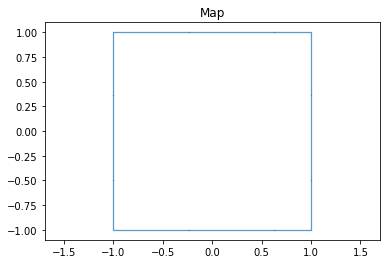

In [1]:
import numpy as np
import matplotlib.pyplot as plt


# Create a fake map (2x2 meter empty square, with 1mm resolution)
map = []
# North wall
map.extend([[x, -1] for x in np.arange(-1, 1, 0.01)])
# East wall
map.extend([[1, y] for y in np.arange(-1, 1, 0.01)])
# South wall
map.extend([[x, 1] for x in np.arange(1, -1, -0.01)])
# West wall
map.extend([[-1, y] for y in np.arange(1, -1, -0.01)])
map = np.array(map)

# Plot the map
plt.figure()
plt.scatter(map[:, 0], map[:, 1], s=0.1)
plt.axis('equal')
plt.title('Map')
plt.show()

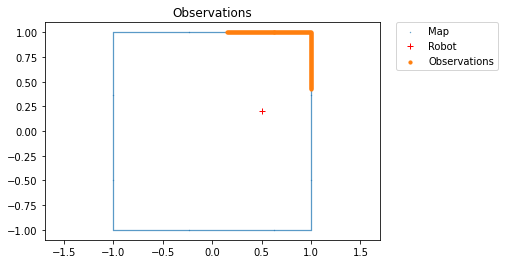

In [2]:
# Create a function that, given a position and a map, returns the range and bearing of
# the edges of the map, assuming a FOV of 90 degrees, a maximum range of 1 meter and
# a total of 90 measurements.
def get_observations(robot_pose, map, fov, max_range):
    """Get the observations from the robot pose and the map.

    Parameters
    ----------
    robot_pose : numpy array
        The robot pose as (x, y, gamma).
    map : numpy array
        The map as an array of (x, y) points.

    Returns
    -------
    numpy array
        The observations as an array of (range, bearing) points.
    """
    # Get the robot pose
    robot_x = robot_pose[0]
    robot_y = robot_pose[1]
    robot_gamma = robot_pose[2]
    # Get the map points
    map_x = map[:, 0]
    map_y = map[:, 1]
    # Calculate the range and bearing
    range = np.linalg.norm(map - robot_pose[0:2], axis=1)
    bearing = np.arctan2(map_y - robot_y, map_x - robot_x) - robot_gamma
    observations = np.array([range, bearing])
    # Filter the observations
    observations = observations[:, (observations[0] < max_range) & (observations[1] < fov / 2) & (observations[1] > -fov / 2)]
    # Return the observations
    return observations.T

# Test the function
robot_pose = np.array([0.5, 0.2, 1.2])
observations = get_observations(robot_pose, map, np.pi / 2, 1)

# Plot the observations
plt.figure()
plt.scatter(map[:, 0], map[:, 1], s=0.1, label='Map')
plt.plot(robot_pose[0], robot_pose[1], 'r+', label='Robot')
plt.scatter(robot_pose[0] + observations[:, 0] * np.cos(observations[:, 1] + robot_pose[2]),
            robot_pose[1] + observations[:, 0] * np.sin(observations[:, 1] + robot_pose[2]), s=10, label='Observations')
plt.axis('equal')
plt.title('Observations')
# Place legend outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()


Step 0
(0, 2)


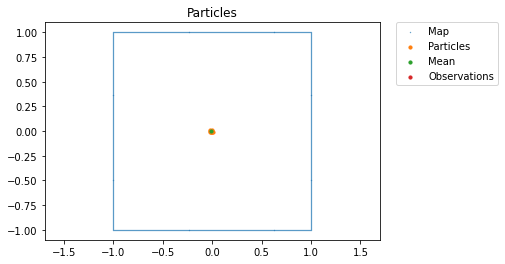

Step 1
(87, 2)


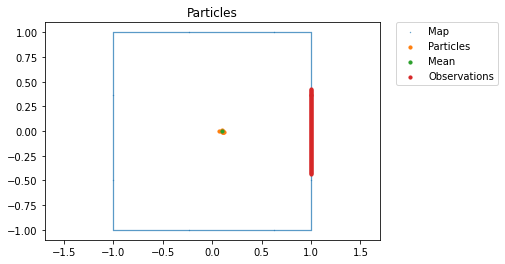

Step 2
(92, 2)
1.901343102993542
1.9128174978928707
1.9145079579561153
1.9137925743980366
1.9119819493386048
1.912831967252625
1.9088287840902072
1.9040058205930603
1.9121819340436184
1.8974331258345782


ValueError: probabilities do not sum to 1

In [3]:
from pygp_particle_filter import ParticleFilter

# Create a particle filter
num_particles = 10
particle_filter = ParticleFilter(num_particles)

num_steps = range(10)

current_time = 0
linear_speed = 0.05
angular_speed = 0.1
observation_std = 0.2
length_scale = 0.1

plt.figure()

for i in num_steps:
    print('Step {}'.format(i))

    control_input = np.array([current_time, linear_speed, angular_speed])

    # Predict the next positions
    particle_filter.predict(control_input)

    # Get the observations
    mean_pose = particle_filter.mean_pose
    observations = get_observations(mean_pose, map, np.pi / 2, 1)

    # Update the weights
    particle_filter.observation_update(observations,  observation_std, length_scale)

    # Get the particles for plotting
    particles_x = [p.x for p in particle_filter.particles]
    particles_y = [p.y for p in particle_filter.particles]

    # Plot the particles
    plt.clf()
    plt.scatter(map[:, 0], map[:, 1], s=0.1, label='Map')
    plt.scatter(particles_x, particles_y, s=10, label='Particles')
    plt.scatter(mean_pose[0], mean_pose[1], s=10, label='Mean')
    plt.scatter(mean_pose[0] + observations[:, 0] * np.cos(observations[:, 1] + mean_pose[2]),
                mean_pose[1] + observations[:, 0] * np.sin(observations[:, 1] + mean_pose[2]), s=10, label='Observations')
    plt.axis('equal')
    plt.title('Particles')
    # Place legend outside the plot
    plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
    plt.show()

    current_time += 1.0

